<a href="https://colab.research.google.com/github/Eng-NadeenShadeed/BinX_AI_ML_Internship/blob/main/Week7/Day%202/day2_cnn_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
from google.colab import drive
drive.mount('/content/drive')
import os

os.chdir('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 2')
print("Working directory:", os.getcwd())
print("Files:", os.listdir('.'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 2
Files: ['day2_cnn_transfer_learning.ipynb']


# Week 7 · Day 2 — Building CNNs & Transfer Learning
**BinX Tech — AI & ML Internship**

Melanoma Skin Cancer Classification — Benign vs Malignant

## From Day 1 to Day 2

On Day 1, I learned that convolution slides a small filter across an image,
computing a dot product at each position to produce a feature map.
One filter detects one pattern — edges, corners, textures — and the same
9 weights are reused everywhere (parameter sharing).

Day 2 builds directly on that. A single convolution layer is not enough
for real image classification. A full CNN stacks multiple operations:

- **Pooling** — shrinks the feature maps after convolution
- **Multiple conv+pool blocks** — builds a feature hierarchy
- **Data augmentation** — artificially expands the training set
- **Transfer learning** — reuses a model already trained on millions of images

By the end of today, I will have trained three models on the Melanoma dataset
and compared their performance.

## Pooling — Shrinking Feature Maps

After convolution produces a feature map, the feature map may still be large.
Pooling is a downsampling operation that reduces its spatial dimensions while
keeping important information.

**Max Pooling** uses a small window, typically 2×2, and keeps the maximum value
from each region. With a 2×2 window and stride 2, the spatial dimensions are
reduced by half, so the total number of values becomes one quarter.

Why keep the maximum?

A large value in a feature map represents a strong response from a filter.
Max pooling keeps the strongest response from each local region and discards
less important responses.

Two main benefits are:

- **Efficiency** — smaller feature maps require less computation and memory.
- **Robustness** — the representation becomes less sensitive to small spatial
  shifts in the detected pattern.

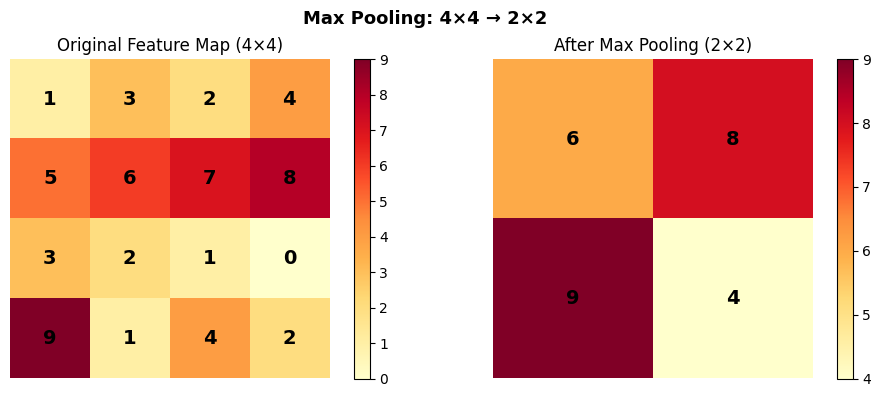

Before pooling: (4, 4) = 16 values
After pooling:  (2, 2) = 4 values
Size reduction: 4×


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simple 4×4 feature map
feature_map = np.array([
    [1, 3, 2, 4],
    [5, 6, 7, 8],
    [3, 2, 1, 0],
    [9, 1, 4, 2]
], dtype=float)

# Max Pooling — 2×2 window, stride 2
def max_pool_2x2(fm):
    h, w = fm.shape
    out = np.zeros((h // 2, w // 2))
    for i in range(0, h, 2):
        for j in range(0, w, 2):
            out[i // 2, j // 2] = fm[i:i+2, j:j+2].max()
    return out

pooled = max_pool_2x2(feature_map)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Max Pooling: 4×4 → 2×2", fontsize=13, fontweight="bold")

im1 = axes[0].imshow(feature_map, cmap="YlOrRd")
axes[0].set_title("Original Feature Map (4×4)")
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, int(feature_map[i, j]),
                     ha="center", va="center", fontsize=14, fontweight="bold")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pooled, cmap="YlOrRd")
axes[1].set_title("After Max Pooling (2×2)")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, int(pooled[i, j]),
                     ha="center", va="center", fontsize=14, fontweight="bold")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Before pooling: {feature_map.shape} = {feature_map.size} values")
print(f"After pooling:  {pooled.shape} = {pooled.size} values")
print(f"Size reduction: {feature_map.size // pooled.size}×")

### What Max Pooling Did

Each 2×2 region kept only its largest value:

| Region | Values | Max kept |
|--------|--------|----------|
| Top-left | 1, 3, 5, 6 | **6** |
| Top-right | 2, 4, 7, 8 | **8** |
| Bottom-left | 3, 2, 9, 1 | **9** |
| Bottom-right | 1, 0, 4, 2 | **4** |

The feature map went from 16 values to 4 — one quarter of the original size.
The maximum value from each local region was preserved, while the other values
were discarded.

In many CNN architectures, pooling is used after convolution blocks to
progressively reduce the spatial size of feature maps while retaining strong
detected patterns.

---

## Full CNN Architecture

A complete CNN stacks convolution and pooling in blocks, then connects
to dense layers for the final classification decision.

Each Conv+Pool block does two things:
- **Conv** — detects patterns using learned filters
- **Pool** — shrinks the result, keeping only the strongest signals

After several blocks, the image has been compressed into a small but
rich representation. A **Flatten** layer converts it into a 1D vector,
and dense layers (like Week 6) make the final classification.

```
Input Image (128×128×3)
↓
Conv Block 1: 32 filters → feature maps → Max Pool → (64×64×32)
↓
Conv Block 2: 64 filters → feature maps → Max Pool → (32×32×64)
↓
Flatten → (65,536 values)
↓
Dense (64 neurons) → ReLU
↓
Dense (1 neuron) → Sigmoid → Benign or Malignant
```


Why does the number of filters grow (32 → 64)?
Early layers detect simple patterns (edges) — a few filters are enough.
Deeper layers combine those into complex patterns (shapes, textures) —
more filters are needed to capture the variety.


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Build a CNN from scratch for binary classification
# (benign vs malignant)
def build_cnn(input_shape=(128, 128, 3)):
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Classification head
        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")  # binary: benign=0, malignant=1
    ])

    return model


# Build the model
model = build_cnn()

# Display the architecture and parameter counts
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,529 (8.36 MB)

 Trainable params: 2,190,529 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

### Reading the Model Summary

The `model.summary()` output shows the structure of the CNN and the number
of parameters used by each layer.

The key columns are:

| Column | Meaning |
|--------|---------|
| Layer (type) | The name and type of the layer |
| Output Shape | The shape of the data after passing through the layer |
| Param # | The number of learnable parameters in that layer |

**What I can observe from this model:**

- The input image has a shape of **128 × 128 × 3**, where 3 represents the RGB channels.
- After each MaxPooling layer, the spatial dimensions are reduced by half:
  **128 → 64 → 32 → 16**.
- The number of feature channels increases as the network gets deeper:
  **32 → 64 → 128**.
- The convolutional layers learn their filters from the training data.
  For example, the first Conv2D layer has **896 parameters**.
- Pooling, Flatten, and Dropout have **0 trainable parameters** because they
  do not learn weights.
- After the final pooling layer, the representation has shape
  **16 × 16 × 128**, which becomes **32,768 values** after Flatten.
- The Dense(64) layer contains **2,097,216 parameters**, showing that the
  classification head can contain many more parameters than the convolutional
  layers.
- The final Dense(1) layer contains **65 parameters** and uses sigmoid to
  produce a probability between 0 and 1 for binary classification.

The model has a total of **2,190,529 trainable parameters**.

This model is built from scratch, meaning these parameters are initialized
before training and will be learned from the Melanoma images during training.

---

## Data Augmentation

11,890 images sounds like a lot, but for a CNN training from scratch it is
relatively small. The network can memorize the training images instead of
learning general patterns — this is overfitting.

Data augmentation artificially expands the dataset by applying random
transformations to each image every time it is shown during training:
flips, rotations, zooms, and shifts. The label stays the same — a flipped
melanoma image is still melanoma — but the network sees a slightly different
version each time, forcing it to learn patterns that generalize.

| Transformation | What it does |
|---------------|-------------|
| Random Flip | Mirrors the image horizontally or vertically |
| Random Rotation | Rotates up to a set angle |
| Random Zoom | Zooms in or out slightly |
| Random Brightness | Slightly changes lighting conditions |

Augmentation is applied only during training — never during validation or testing.
The validation set must reflect real, unmodified images to give an honest
measure of performance.

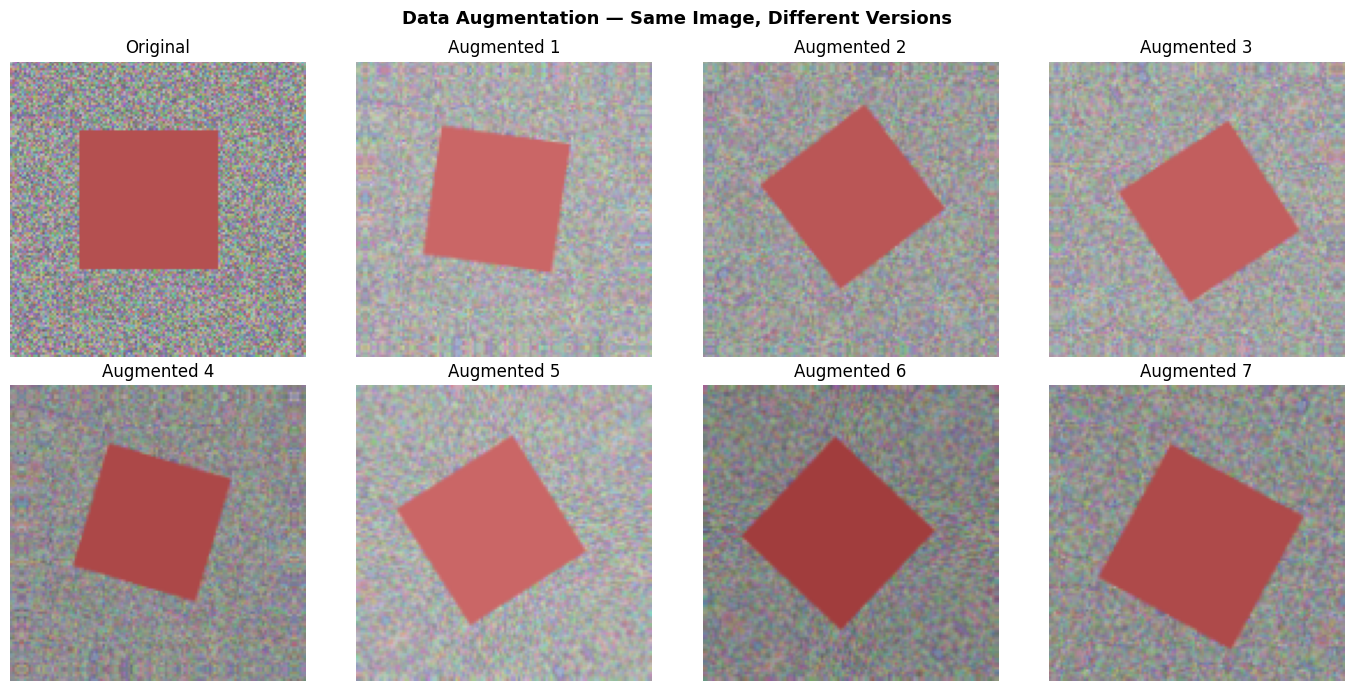

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom, RandomBrightness
)
import matplotlib.pyplot as plt
import numpy as np

# Define augmentation pipeline
augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.15),
    RandomZoom(0.1),
    RandomBrightness(0.1),
], name="augmentation")

# Visualize augmentation on a synthetic image
# (real images will be loaded in the Hands-On Lab)
np.random.seed(42)
sample = np.random.randint(100, 200, (128, 128, 3), dtype=np.uint8)
sample[30:90, 30:90] = [180, 80, 80]   # simulate a lesion region
sample_tensor = tf.expand_dims(tf.cast(sample, tf.float32), 0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Data Augmentation — Same Image, Different Versions",
             fontsize=13, fontweight="bold")

axes[0, 0].imshow(sample)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for i, ax in enumerate(axes.flat[1:]):
    augmented = augmentation(sample_tensor, training=True)
    aug_img = tf.squeeze(augmented).numpy().astype(np.uint8)
    ax.imshow(aug_img)
    ax.set_title(f"Augmented {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### What Augmentation Does to Training

Without augmentation, the network sees each training image exactly once
per epoch. With augmentation, every image looks slightly different each
epoch — the network cannot memorize positions or orientations.

The effect shows up in the training curves:
- **Without augmentation:** training accuracy climbs fast, validation
  accuracy lags behind — classic overfitting
- **With augmentation:** the gap between training and validation narrows —
  the network is learning patterns, not memorizing images

One important detail: augmentation adds no new information. It only
presents existing information in more varied forms. It is not a substitute
for collecting more real data — but it is the standard first defense
against overfitting in computer vision.

---

## Transfer Learning

Training a CNN from scratch needs two things: a large dataset and significant
compute time. For many real-world tasks — including medical imaging — neither
is available in abundance.

Transfer learning solves this by reusing a model already trained on millions
of images. Instead of learning every filter from random weights, I start with
a model that already knows how to detect edges, textures, shapes, and complex
visual patterns — then adapt it to the specific task.

The process has two steps:

**Step 1 — Use a pretrained base (frozen)**
Take a model like MobileNetV2, trained on ImageNet (1.2 million images,
1,000 classes). Remove its final classification layer. Freeze all its weights
so they do not change during training. Add a new classification head for
the target task (benign vs malignant).

**Step 2 — Fine-tuning (optional)**
After the new head has learned, unfreeze some of the deeper layers and
train at a very low learning rate. This lets the pretrained features adapt
slightly to the new domain.

Why does this work?
The early layers of any CNN trained on natural images learn universal features —
edges, corners, color gradients. These features are useful for almost any
image task, including melanoma classification. Only the deeper, task-specific
layers need to change.

### Why MobileNetV2?

Several pretrained models are available in Keras Applications.
MobileNetV2 is the right choice for this task:

| Model | Parameters | Speed | Accuracy |
|-------|-----------|-------|----------|
| VGG16 | 138M | Slow | Good |
| ResNet50 | 25M | Medium | Very good |
| **MobileNetV2** | **3.4M** | **Fast** | **Good** |
| EfficientNetB0 | 5.3M | Fast | Very good |

MobileNetV2 is lightweight and fast — ideal for a dataset of ~12K images
on a free Colab GPU. It trains quickly, overfits less, and still produces
strong results on medical image tasks.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout
)

def build_transfer_model(input_shape=(128, 128, 3)):
    # Load MobileNetV2 pretrained on ImageNet
    # include_top=False removes the final classification layer
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    # Freeze all pretrained layers
    # Their weights will not change during training
    base_model.trainable = False

    # Build the full model
    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)   # replaces Flatten — more efficient
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    return model, base_model

transfer_model, base_model = build_transfer_model()
transfer_model.summary()

print(f"\nTotal layers in base model   : {len(base_model.layers)}")
print(f"Trainable parameters         : {transfer_model.trainable_variables.__len__()}")

# Show frozen vs trainable
total     = sum(tf.size(v).numpy() for v in transfer_model.variables)
trainable = sum(tf.size(v).numpy() for v in transfer_model.trainable_variables)
frozen    = total - trainable

print(f"\nTotal parameters   : {total:,}")
print(f"Trainable (new head): {trainable:,}")
print(f"Frozen (pretrained) : {frozen:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total layers in base model   : 154
Trainable parameters         : 2

Total parameters   : 2,259,267
Trainable (new head): 1,281
Frozen (pretrained) : 2,257,986


### Frozen vs Trainable — What This Means

When I freeze the base model:
- The **3.4 million pretrained weights** stay exactly as ImageNet trained them
- Only the **new classification head** (a few thousand weights) is trained
- Training is fast because almost nothing changes

The pretrained weights already know how to detect visual patterns.
I am only teaching the final layer to map those patterns to
"benign" or "malignant" instead of ImageNet's 1,000 categories.

### GlobalAveragePooling2D vs Flatten

Instead of Flatten (which creates a very long vector), I use
GlobalAveragePooling2D — it takes the average of each feature map,
producing one number per filter. This is more compact, reduces
overfitting, and is standard practice with pretrained models.

| | Output size (for 4×4×1280 feature maps) |
|--|--|
| Flatten | 4 × 4 × 1280 = **20,480** values |
| GlobalAveragePooling2D | **1,280** values |

---

## Summary — Learning Notebook

| Concept | Key Takeaway |
|---------|-------------|
| Pooling | Shrinks feature maps by keeping the max value in each window |
| Full CNN | Conv+Pool blocks extract features → Flatten → Dense classifies |
| Filters grow deeper | Early layers: simple patterns — deep layers: complex patterns |
| Data augmentation | Random transformations expand training variety and reduce overfitting |
| Transfer learning | Reuse pretrained weights — only train the new classification head |
| MobileNetV2 | 3.4M parameters, fast, strong — right choice for this dataset size |
| Frozen layers | 3.4M pretrained weights unchanged — only the head trains |

**Next:** Hands-On Lab — applying all of this to the real Melanoma dataset.
Training three models, comparing their performance, and documenting which
approach works best and why.